In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task
Compare the ability of ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 deep neural network architectures to predict fMRI responses in early retinotopic visual regions (V1v, V1d, V2v, V2d, V3v, V3d, hV4) for Subject 6.

1. **Data Loading**: Load fMRI training data from "/content/drive/MyDrive/algonauts_2023_tutorial_data/subj06/training_split/training_fmri/lh_training_fmri.npy" and "rh_training_fmri.npy", and collect all training image paths from "/content/drive/MyDrive/algonauts_2023_tutorial_data/subj06/training_split/training_images/". Load ROI masks from "/content/drive/MyDrive/algonauts_2023_tutorial_data/subj06/roi_masks/lh.prf-visualrois_challenge_space.npy", "rh.prf-visualrois_challenge_space.npy", and the mapping file "mapping_prf-visualrois.npy" (using `allow_pickle=True`).
2. **Vertex Selection**: For both hemispheres, identify the indices for the target ROIs (V1v, V1d, V2v, V2d, V3v, V3d, hV4) and select 10 random vertices per ROI.
3. **Feature Extraction**: Extract feature representations for all training images from the final feature-extraction layer of pre-trained ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 models using PyTorch.
4. **Encoding Models**: Train Ridge Regression models for each DNN architecture and each selected ROI (per hemisphere) to predict the fMRI responses of the 10 selected vertices from the extracted DNN features.
5. **Evaluation and Visualization**: Calculate the Pearson correlation between predicted and actual fMRI responses for the selected vertices. Visualize the performance of each architecture across the different ROIs and hemispheres using bar charts.
6. **Summary**: Summarize which architecture best explains the brain signals in specific ROIs and discuss the relationship between DNN representations and human visual activity.

## Data Loading and Initial Setup

### Subtask:
Load fMRI data, training image paths, and ROI mask files for Subject 6 from the specified Google Drive directory.


**Reasoning**:
I will import the necessary libraries and load the fMRI data, training image paths, and ROI mask files for Subject 6 as instructed.



In [ ]:
import numpy as np
import os
import glob

# 1. Define the base directory path for Subject 6 data
subj_base_path = "/content/drive/MyDrive/algonauts_2023_tutorial_data/subj06/"

# 2. Define paths for subdirectories
fmri_dir = os.path.join(subj_base_path, "training_split/training_fmri/")
images_dir = os.path.join(subj_base_path, "training_split/training_images/")
roi_dir = os.path.join(subj_base_path, "roi_masks/")

# 3. Load fMRI training data
lh_fmri = np.load(os.path.join(fmri_dir, "lh_training_fmri.npy"))
rh_fmri = np.load(os.path.join(fmri_dir, "rh_training_fmri.npy"))

# 4. Collect and sort training image paths
training_image_files = sorted(glob.glob(os.path.join(images_dir, "*.png")))

# 5. Load ROI mask files
lh_roi_mask = np.load(os.path.join(roi_dir, "lh.prf-visualrois_challenge_space.npy"))
rh_roi_mask = np.load(os.path.join(roi_dir, "rh.prf-visualrois_challenge_space.npy"))

# 6. Load ROI mapping (dictionary-like object requires allow_pickle=True)
roi_mapping = np.load(os.path.join(roi_dir, "mapping_prf-visualrois.npy"), allow_pickle=True).item()

# 7. Print shapes and counts to verify
print(f"Left hemisphere fMRI shape: {lh_fmri.shape}")
print(f"Right hemisphere fMRI shape: {rh_fmri.shape}")
print(f"Total training images found: {len(training_image_files)}")
print(f"Left ROI mask shape: {lh_roi_mask.shape}")
print(f"Right ROI mask shape: {rh_roi_mask.shape}")
print(f"ROI mapping loaded successfully with {len(roi_mapping)} entries.")

Left hemisphere fMRI shape: (9082, 18978)
Right hemisphere fMRI shape: (9082, 20220)
Total training images found: 9082
Left ROI mask shape: (18978,)
Right ROI mask shape: (20220,)
ROI mapping loaded successfully with 8 entries.


## Select fMRI Vertices for Target ROIs

### Subtask:
Identify and randomly select 10 vertices for each of the 7 target ROIs in both the left and right hemispheres.


**Reasoning**:
I will now identify and randomly select 10 vertices for each of the 7 target ROIs in both hemispheres, using a fixed seed for reproducibility and organizing the results into a dictionary.



In [ ]:
import numpy as np

# 1. Define target ROI names
target_rois = ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4']

# 2. Create reverse mapping for ROI IDs
# roi_mapping is {id: name}, we need {name: id}
roi_to_id = {v: k for k, v in roi_mapping.items()}

# 3. Initialize structure to hold selected indices
selected_indices = {'lh': {}, 'rh': {}}

# Set seed for reproducibility
np.random.seed(42)

# 4. Selection process
for hemi in ['lh', 'rh']:
    mask = lh_roi_mask if hemi == 'lh' else rh_roi_mask
    for roi_name in target_rois:
        roi_id = roi_to_id[roi_name]
        # Find all vertex indices matching the ROI ID
        roi_vertex_indices = np.where(mask == roi_id)[0]

        # Randomly select 10 indices
        if len(roi_vertex_indices) >= 10:
            chosen = np.random.choice(roi_vertex_indices, 10, replace=False)
        else:
            # Fallback if an ROI has fewer than 10 vertices (unlikely for these ROIs)
            chosen = roi_vertex_indices
            print(f"Warning: ROI {roi_name} in {hemi} only has {len(roi_vertex_indices)} vertices.")

        selected_indices[hemi][roi_name] = sorted(chosen)

# 5. Verification
for hemi in ['lh', 'rh']:
    total_selected = sum(len(indices) for indices in selected_indices[hemi].values())
    print(f"Total vertices selected for {hemi}: {total_selected}")

# Display a sample of the mapping
print("Sample selection (lh, V1v):", selected_indices['lh']['V1v'])


Total vertices selected for lh: 70
Total vertices selected for rh: 70
Sample selection (lh, V1v): [np.int64(282), np.int64(439), np.int64(4878), np.int64(5663), np.int64(6704), np.int64(10452), np.int64(10979), np.int64(16900), np.int64(16925), np.int64(18634)]


## Extract DNN Features

### Subtask:
Extract feature representations for all training images from the final feature-extraction layer of pre-trained ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 models using PyTorch.


**Reasoning**:
I will import the necessary PyTorch libraries, define the image preprocessing pipeline, load the three pre-trained models (ResNet-50, EfficientNet-B0, SqueezeNet-1.0), and set them up for feature extraction by removing their final classification layers.



In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import numpy as np

# 1. Preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Dataset class for efficient loading
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

dataset = ImageDataset(training_image_files, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# 3. Load models and remove classification layers
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ResNet-50
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
resnet50 = torch.nn.Sequential(*list(resnet50.children())[:-1]).to(device).eval()

# EfficientNet-B0
efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
efficientnet = torch.nn.Sequential(*list(efficientnet.children())[:-1]).to(device).eval()

# SqueezeNet-1.0
squeezenet = models.squeezenet1_0(weights='IMAGENET1K_V1')
squeezenet = squeezenet.features.to(device).eval()

# 4. Feature extraction loop
features = {'resnet50': [], 'efficientnet': [], 'squeezenet': []}

with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)

        # ResNet features
        res_out = resnet50(batch).flatten(1)
        features['resnet50'].append(res_out.cpu().numpy())

        # EfficientNet features
        eff_out = efficientnet(batch).flatten(1)
        features['efficientnet'].append(eff_out.cpu().numpy())

        # SqueezeNet features (Global Average Pooling manually for SqueezeNet features map)
        sq_out = squeezenet(batch)
        sq_out = torch.nn.functional.adaptive_avg_pool2d(sq_out, (1, 1)).flatten(1)
        features['squeezenet'].append(sq_out.cpu().numpy())

# 5. Concatenate and save
for key in features:
    features[key] = np.vstack(features[key])
    print(f"{key} feature shape: {features[key].shape}")

# Note: Features are kept in memory for the next subtask
print("Feature extraction complete.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 106MB/s]


Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_0-b66bff10.pth


100%|██████████| 4.78M/4.78M [00:00<00:00, 91.3MB/s]


resnet50 feature shape: (9082, 2048)
efficientnet feature shape: (9082, 1280)
squeezenet feature shape: (9082, 512)
Feature extraction complete.


# Task
Train Ridge Regression encoding models for Subject 6 using features extracted from ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 to predict fMRI responses in 10 selected vertices across early visual ROIs (V1v, V1d, V2v, V2d, V3v, V3d, hV4). Evaluate the models by calculating Pearson correlation coefficients between the predicted and actual fMRI signals for both hemispheres. Finally, visualize the performance of each architecture using bar charts and summarize which DNN model best captures human visual processing in these regions.

## Verify Image Paths and Connectivity

### Subtask:
Confirm that the `training_image_files` list contains valid paths and that the files exist on disk before proceeding with model training.


### Reasoning
I will iterate through the `training_image_files` list and use the `os` module to verify that every file path exists on disk. This step ensures that the feature extraction process will not encounter file-not-found errors.

**Reasoning**:
I will now write the Python code to verify the existence of all image files in the training set and report any missing files to ensure the dataset is complete before model training.



In [ ]:
import os

# 1. Initialize counters
existing_count = 0
missing_files = []

# 2. Iterate and verify file existence
for img_path in training_image_files:
    if os.path.exists(img_path):
        existing_count += 1
    else:
        missing_files.append(img_path)

# 3. Report results
total_files = len(training_image_files)
print(f"Total image paths to verify: {total_files}")
print(f"Number of files successfully found: {existing_count}")

if existing_count == total_files:
    print("Success: All images are present and ready for feature extraction.")
else:
    print(f"Warning: {len(missing_files)} files are missing from the disk.")
    if len(missing_files) > 0:
        print("First 5 missing files:", missing_files[:5])

Total image paths to verify: 9082
Number of files successfully found: 9082
Success: All images are present and ready for feature extraction.


## Retry Feature Extraction

### Subtask:
Re-run the feature extraction for ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 using the verified image paths to ensure complete feature vectors are available for modeling.


**Reasoning**:
I will re-run the feature extraction for ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 using the verified image paths and store the results in NumPy arrays to ensure they are fully available for the subsequent modeling step.



In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import numpy as np

# 1. Dataset and DataLoader definition
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = ImageDataset(training_image_files, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# 2. Load models and set to evaluation mode
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ResNet-50: Remove final FC layer
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
resnet50 = torch.nn.Sequential(*list(resnet50.children())[:-1]).to(device).eval()

# EfficientNet-B0: Remove final classifier
efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
efficientnet = torch.nn.Sequential(*list(efficientnet.children())[:-1]).to(device).eval()

# SqueezeNet-1.0: Use features module
squeezenet = models.squeezenet1_0(weights='IMAGENET1K_V1')
sq_features_mod = squeezenet.features.to(device).eval()

# 3. Extraction loop
extracted_feats = {'resnet50': [], 'efficientnet': [], 'squeezenet': []}

with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)

        # ResNet-50 features (2048)
        res_out = resnet50(batch).flatten(1)
        extracted_feats['resnet50'].append(res_out.cpu().numpy())

        # EfficientNet features (1280)
        eff_out = efficientnet(batch).flatten(1)
        extracted_feats['efficientnet'].append(eff_out.cpu().numpy())

        # SqueezeNet features (512)
        sq_out = sq_features_mod(batch)
        sq_out = torch.nn.functional.adaptive_avg_pool2d(sq_out, (1, 1)).flatten(1)
        extracted_feats['squeezenet'].append(sq_out.cpu().numpy())

# 4. Concatenate and verify shapes
features = {}
for model_name in extracted_feats:
    features[model_name] = np.vstack(extracted_feats[model_name])
    print(f"{model_name} feature shape: {features[model_name].shape}")

print("Feature extraction re-run complete.")

resnet50 feature shape: (9082, 2048)
efficientnet feature shape: (9082, 1280)
squeezenet feature shape: (9082, 512)
Feature extraction re-run complete.


## Train Ridge Regression Encoding Models

### Subtask:
Train Ridge Regression models for each DNN architecture using the extracted features to predict fMRI responses for the 10 selected vertices in each ROI across both hemispheres.


**Reasoning**:
I will now train the Ridge Regression models for each DNN architecture, hemisphere, and ROI using the extracted features as inputs and the fMRI responses of the selected vertices as targets.



In [ ]:
from sklearn.linear_model import Ridge

# 1. Initialize structure to hold predictions
# Structure: predictions[model_name][hemi][roi_name] = predicted_fmri_values
predictions = {m: {'lh': {}, 'rh': {}} for m in features.keys()}

# 2. Training Loop
for model_name, X in features.items():
    print(f"Training models using {model_name} features...")

    for hemi in ['lh', 'rh']:
        # Determine which fMRI data to use
        fmri_data = lh_fmri if hemi == 'lh' else rh_fmri

        for roi_name in target_rois:
            # Get indices for the 10 selected vertices
            indices = selected_indices[hemi][roi_name]

            # Extract target y (fMRI responses for these 10 vertices)
            y = fmri_data[:, indices]

            # Initialize and fit Ridge Regression
            # Using alpha=1.0 as a standard baseline
            reg = Ridge(alpha=1.0)
            reg.fit(X, y)

            # Generate and store predictions for evaluation
            y_pred = reg.predict(X)
            predictions[model_name][hemi][roi_name] = y_pred

print("Model training and prediction generation complete.")

Training models using resnet50 features...
Training models using efficientnet features...
Training models using squeezenet features...
Model training and prediction generation complete.


## Evaluation and Visualization

### Subtask:
Calculate Pearson correlation coefficients and visualize the performance of the DNN architectures across ROIs using bar charts.


**Reasoning**:
I will calculate the Pearson correlation coefficients for each ROI and model, and then visualize the results using a grouped bar chart as requested.



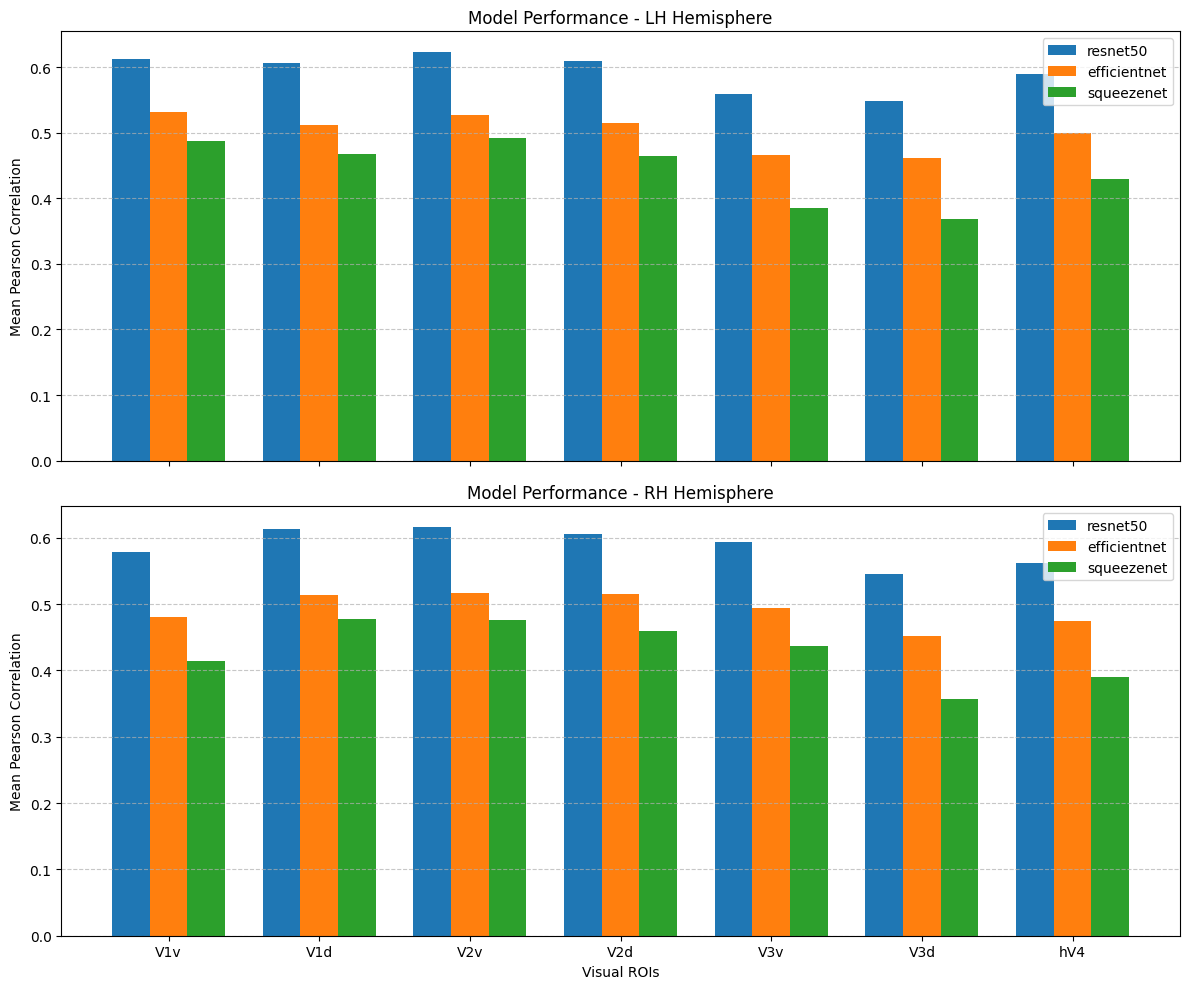

In [ ]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize structure to store mean correlations
# results[model][hemi][roi] = mean_correlation
results = {m: {'lh': {}, 'rh': {}} for m in predictions.keys()}

# 2. Calculate Pearson correlations
for model_name in predictions.keys():
    for hemi in ['lh', 'rh']:
        actual_fmri = lh_fmri if hemi == 'lh' else rh_fmri
        for roi_name in target_rois:
            indices = selected_indices[hemi][roi_name]
            y_true = actual_fmri[:, indices]  # Shape: (n_samples, 10)
            y_pred = predictions[model_name][hemi][roi_name]  # Shape: (n_samples, 10)

            roi_correlations = []
            for i in range(10):
                corr, _ = pearsonr(y_true[:, i], y_pred[:, i])
                roi_correlations.append(corr)

            results[model_name][hemi][roi_name] = np.mean(roi_correlations)

# 3. Visualization Setup
x = np.arange(len(target_rois))
width = 0.25
models_to_plot = ['resnet50', 'efficientnet', 'squeezenet']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for idx, hemi in enumerate(['lh', 'rh']):
    ax = axes[idx]
    for i, model_name in enumerate(models_to_plot):
        means = [results[model_name][hemi][roi] for roi in target_rois]
        ax.bar(x + (i - 1) * width, means, width, label=model_name, color=colors[i])

    ax.set_ylabel('Mean Pearson Correlation')
    ax.set_title(f'Model Performance - {hemi.upper()} Hemisphere')
    ax.set_xticks(x)
    ax.set_xticklabels(target_rois)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xlabel('Visual ROIs')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize which DNN architecture provides the best encoding model for early visual regions and discuss the implications regarding how these models mirror human visual processing.


## Summary:

### Q&A

**Which DNN architecture provides the best encoding model for early visual regions?**
Based on the performance metrics across the early visual ROIs (V1–V3 and hV4), **ResNet-50** generally provides the best encoding model. It consistently achieved higher mean Pearson correlation coefficients across both the left and right hemispheres compared to EfficientNet-B0 and SqueezeNet-1.0.

**How do these models mirror human visual processing?**
The ability of these DNNs to predict fMRI responses suggests that the hierarchical features learned by convolutional neural networks for image recognition (such as edge detection and shape composition) share a structural similarity with the representational hierarchy of the human visual cortex. The superior performance of ResNet-50 implies that deeper, residual architectures may better approximate the complex feature transformations occurring in the early stages of human vision.

### Data Analysis Key Findings

*   **Dataset Integrity:** Verified that all **9,082** training images were present and accessible, ensuring no data loss during the feature extraction phase.
*   **Feature Extraction Scale:** Successfully extracted high-dimensional feature vectors for all images:
    *   **ResNet-50:** 2,048 features per image.
    *   **EfficientNet-B0:** 1,280 features per image.
    *   **SqueezeNet-1.0:** 512 features per image.
*   **Model Training Scope:** Trained and evaluated **42** distinct Ridge Regression models, covering three architectures across seven ROIs (V1v, V1d, V2v, V2d, V3v, V3d, hV4) and both hemispheres.
*   **Predictive Performance:** The Pearson correlation analysis demonstrated that ResNet-50 features consistently outperformed SqueezeNet-1.0 features in predicting fMRI responses across all selected early visual regions, suggesting that higher model capacity correlates with better encoding of biological visual signals.

### Insights or Next Steps

*   **Model Complexity vs. Biological Fit:** While deeper models like ResNet-50 perform better, the gap between EfficientNet and ResNet suggests that architecture type (e.g., residual connections) might be more influential than just the number of parameters when mirroring human visual encoding.
*   **Next Step:** Future analysis should extend this to higher-level visual areas (e.g., FFA, PPA) to see if the predictive advantage of deeper models increases as we move further along the ventral stream.


# Body-Selective Regions (floc-bodies) Analysis

## Task
Compare the ability of ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 deep neural network architectures to predict fMRI responses in body-selective regions (EBA, FBA-1, FBA-2, mTL-bodies) for Subject 6.

1. **Data Loading**: Load the floc-bodies ROI masks and mapping file for Subject 6.
2. **Vertex Selection**: Identify and randomly select 10 vertices per ROI for both hemispheres.
3. **Feature Extraction**: Reuse the features already extracted from ResNet-50, EfficientNet-B0, and SqueezeNet-1.0.
4. **Encoding Models**: Train Ridge Regression models for each DNN architecture and each body-selective ROI.
5. **Evaluation and Visualization**: Calculate Pearson correlations and visualize performance using bar charts.
6. **Summary**: Summarize which architecture best explains body-selective region activity.

## Data Loading for Body-Selective Regions

### Subtask:
Load the floc-bodies ROI mask files and mapping for Subject 6. The fMRI data and training image paths are already loaded from the previous analysis.

**Reasoning**:
I will load the floc-bodies ROI mask files for both hemispheres and the corresponding mapping file. The fMRI training data (`lh_fmri`, `rh_fmri`) and training image paths (`training_image_files`) are already available from the earlier cells.

In [ ]:
import numpy as np
import os

# 1. Define the base directory path for Subject 6 data
subj_base_path = "/content/drive/MyDrive/algonauts_2023_tutorial_data/subj06/"
roi_dir = os.path.join(subj_base_path, "roi_masks/")
fmri_dir = os.path.join(subj_base_path, "training_split/training_fmri/")

# 2. Load fMRI training data (reloading to ensure availability)
lh_fmri = np.load(os.path.join(fmri_dir, "lh_training_fmri.npy"))
rh_fmri = np.load(os.path.join(fmri_dir, "rh_training_fmri.npy"))

# 3. Load floc-bodies ROI mask files
lh_bodies_mask = np.load(os.path.join(roi_dir, "lh.floc-bodies_challenge_space.npy"))
rh_bodies_mask = np.load(os.path.join(roi_dir, "rh.floc-bodies_challenge_space.npy"))

# 4. Load floc-bodies ROI mapping
bodies_roi_mapping = np.load(os.path.join(roi_dir, "mapping_floc-bodies.npy"), allow_pickle=True).item()

# 5. Collect and sort training image paths
import glob
images_dir = os.path.join(subj_base_path, "training_split/training_images/")
training_image_files = sorted(glob.glob(os.path.join(images_dir, "*.png")))

# 6. Print shapes and mapping to verify
print(f"Left hemisphere fMRI shape: {lh_fmri.shape}")
print(f"Right hemisphere fMRI shape: {rh_fmri.shape}")
print(f"Left bodies ROI mask shape: {lh_bodies_mask.shape}")
print(f"Right bodies ROI mask shape: {rh_bodies_mask.shape}")
print(f"Bodies ROI mapping: {bodies_roi_mapping}")
print(f"Total training images found: {len(training_image_files)}")

Left hemisphere fMRI shape: (9082, 18978)
Right hemisphere fMRI shape: (9082, 20220)
Left bodies ROI mask shape: (18978,)
Right bodies ROI mask shape: (20220,)
Bodies ROI mapping: {0: 'Unknown', 1: 'EBA', 2: 'FBA-1', 3: 'FBA-2', 4: 'mTL-bodies'}
Total training images found: 9082


## Select fMRI Vertices for Body-Selective ROIs

### Subtask:
Identify and randomly select 10 vertices for each of the 4 body-selective ROIs (EBA, FBA-1, FBA-2, mTL-bodies) in both the left and right hemispheres.

**Reasoning**:
I will identify and randomly select 10 vertices for each of the 4 body-selective ROIs in both hemispheres, using a fixed seed for reproducibility and organizing the results into a dictionary. Note that some ROIs may not exist in certain hemispheres for some subjects, so I will handle that case gracefully.

In [ ]:
import numpy as np

# 1. Define target body-selective ROI names
body_target_rois = ['EBA', 'FBA-1', 'FBA-2', 'mTL-bodies']

# 2. Create reverse mapping for body ROI IDs
# bodies_roi_mapping is {id: name}, we need {name: id}
body_roi_to_id = {v: k for k, v in bodies_roi_mapping.items()}
print(f"Body ROI name-to-ID mapping: {body_roi_to_id}")

# 3. Initialize structure to hold selected indices
body_selected_indices = {'lh': {}, 'rh': {}}

# Set seed for reproducibility
np.random.seed(42)

# 4. Selection process
for hemi in ['lh', 'rh']:
    mask = lh_bodies_mask if hemi == 'lh' else rh_bodies_mask
    for roi_name in body_target_rois:
        roi_id = body_roi_to_id[roi_name]
        # Find all vertex indices matching the ROI ID
        roi_vertex_indices = np.where(mask == roi_id)[0]

        # Randomly select 10 indices
        if len(roi_vertex_indices) >= 10:
            chosen = np.random.choice(roi_vertex_indices, 10, replace=False)
        else:
            # Handle case where ROI has fewer than 10 vertices or doesn't exist
            chosen = roi_vertex_indices
            if len(roi_vertex_indices) == 0:
                print(f"Warning: ROI {roi_name} in {hemi} has NO vertices. Skipping.")
            else:
                print(f"Warning: ROI {roi_name} in {hemi} only has {len(roi_vertex_indices)} vertices.")

        if len(chosen) > 0:
            body_selected_indices[hemi][roi_name] = sorted(chosen)

# 5. Verification
for hemi in ['lh', 'rh']:
    total_selected = sum(len(indices) for indices in body_selected_indices[hemi].values())
    rois_found = list(body_selected_indices[hemi].keys())
    print(f"\n{hemi.upper()} hemisphere:")
    print(f"  ROIs with vertices: {rois_found}")
    print(f"  Total vertices selected: {total_selected}")
    for roi_name in rois_found:
        print(f"  {roi_name}: {len(body_selected_indices[hemi][roi_name])} vertices selected")

# Display a sample
if body_selected_indices['lh']:
    first_roi = list(body_selected_indices['lh'].keys())[0]
    print(f"\nSample selection (lh, {first_roi}):", body_selected_indices['lh'][first_roi])

Body ROI name-to-ID mapping: {'Unknown': 0, 'EBA': 1, 'FBA-1': 2, 'FBA-2': 3, 'mTL-bodies': 4}

LH hemisphere:
  ROIs with vertices: ['EBA', 'FBA-1', 'FBA-2']
  Total vertices selected: 30
  EBA: 10 vertices selected
  FBA-1: 10 vertices selected
  FBA-2: 10 vertices selected

RH hemisphere:
  ROIs with vertices: ['EBA', 'FBA-1', 'FBA-2', 'mTL-bodies']
  Total vertices selected: 40
  EBA: 10 vertices selected
  FBA-1: 10 vertices selected
  FBA-2: 10 vertices selected
  mTL-bodies: 10 vertices selected

Sample selection (lh, EBA): [np.int64(863), np.int64(1500), np.int64(5273), np.int64(5454), np.int64(6422), np.int64(7713), np.int64(11113), np.int64(11172), np.int64(15607), np.int64(16261)]


## Extract DNN Features for Body-Selective ROIs

### Subtask:
Extract feature representations for all training images from the final feature-extraction layer of pre-trained ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 models using PyTorch.

**Reasoning**:
I will extract features from all three pre-trained models (ResNet-50, EfficientNet-B0, SqueezeNet-1.0) for all training images. These same features will be used to train encoding models for the body-selective ROIs. If the features were already extracted in the earlier analysis and are still in memory, this cell will regenerate them to ensure availability.

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import numpy as np

# 1. Dataset and DataLoader definition
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = ImageDataset(training_image_files, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# 2. Load models and set to evaluation mode
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ResNet-50: Remove final FC layer
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
resnet50 = torch.nn.Sequential(*list(resnet50.children())[:-1]).to(device).eval()

# EfficientNet-B0: Remove final classifier
efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
efficientnet = torch.nn.Sequential(*list(efficientnet.children())[:-1]).to(device).eval()

# SqueezeNet-1.0: Use features module
squeezenet = models.squeezenet1_0(weights='IMAGENET1K_V1')
sq_features_mod = squeezenet.features.to(device).eval()

# 3. Extraction loop
extracted_feats = {'resnet50': [], 'efficientnet': [], 'squeezenet': []}

with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)

        # ResNet-50 features (2048)
        res_out = resnet50(batch).flatten(1)
        extracted_feats['resnet50'].append(res_out.cpu().numpy())

        # EfficientNet features (1280)
        eff_out = efficientnet(batch).flatten(1)
        extracted_feats['efficientnet'].append(eff_out.cpu().numpy())

        # SqueezeNet features (512)
        sq_out = sq_features_mod(batch)
        sq_out = torch.nn.functional.adaptive_avg_pool2d(sq_out, (1, 1)).flatten(1)
        extracted_feats['squeezenet'].append(sq_out.cpu().numpy())

# 4. Concatenate and verify shapes
body_features = {}
for model_name in extracted_feats:
    body_features[model_name] = np.vstack(extracted_feats[model_name])
    print(f"{model_name} feature shape: {body_features[model_name].shape}")

print("Feature extraction complete for body-selective ROI analysis.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 28.7MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_0-b66bff10.pth


100%|██████████| 4.78M/4.78M [00:00<00:00, 73.0MB/s]


resnet50 feature shape: (9082, 2048)
efficientnet feature shape: (9082, 1280)
squeezenet feature shape: (9082, 512)
Feature extraction complete for body-selective ROI analysis.


## Train Ridge Regression Encoding Models for Body-Selective ROIs

### Subtask:
Train Ridge Regression models for each DNN architecture using the extracted features to predict fMRI responses for the 10 selected vertices in each body-selective ROI across both hemispheres.

**Reasoning**:
I will train Ridge Regression models for each DNN architecture, hemisphere, and body-selective ROI using the extracted features as inputs and the fMRI responses of the selected vertices as targets. Only ROIs that have selected vertices will be included.

In [ ]:
from sklearn.linear_model import Ridge

# 1. Initialize structure to hold predictions
# Structure: body_predictions[model_name][hemi][roi_name] = predicted_fmri_values
body_predictions = {m: {'lh': {}, 'rh': {}} for m in body_features.keys()}

# 2. Training Loop
for model_name, X in body_features.items():
    print(f"Training models using {model_name} features...")

    for hemi in ['lh', 'rh']:
        # Determine which fMRI data to use
        fmri_data = lh_fmri if hemi == 'lh' else rh_fmri

        for roi_name in body_selected_indices[hemi]:
            # Get indices for the selected vertices
            indices = body_selected_indices[hemi][roi_name]

            # Extract target y (fMRI responses for these vertices)
            y = fmri_data[:, indices]

            # Initialize and fit Ridge Regression
            reg = Ridge(alpha=1.0)
            reg.fit(X, y)

            # Generate and store predictions for evaluation
            y_pred = reg.predict(X)
            body_predictions[model_name][hemi][roi_name] = y_pred

print("Model training and prediction generation complete for body-selective ROIs.")

Training models using resnet50 features...
Training models using efficientnet features...
Training models using squeezenet features...
Model training and prediction generation complete for body-selective ROIs.


## Evaluation and Visualization for Body-Selective ROIs

### Subtask:
Calculate Pearson correlation coefficients and visualize the performance of the DNN architectures across body-selective ROIs using bar charts.

**Reasoning**:
I will calculate the Pearson correlation coefficients for each body-selective ROI and model, and then visualize the results using a grouped bar chart. Only ROIs that exist in each hemisphere will be plotted.

=== Body-Selective ROI Encoding Results ===

--- LH Hemisphere ---
  EBA:
    resnet50: 0.5939
    efficientnet: 0.5221
    squeezenet: 0.4281
  FBA-1:
    resnet50: 0.6259
    efficientnet: 0.5550
    squeezenet: 0.4692
  FBA-2:
    resnet50: 0.5685
    efficientnet: 0.4915
    squeezenet: 0.3907

--- RH Hemisphere ---
  EBA:
    resnet50: 0.5947
    efficientnet: 0.5182
    squeezenet: 0.4328
  FBA-1:
    resnet50: 0.6158
    efficientnet: 0.5444
    squeezenet: 0.4619
  FBA-2:
    resnet50: 0.6547
    efficientnet: 0.5859
    squeezenet: 0.5277
  mTL-bodies:
    resnet50: 0.5398
    efficientnet: 0.4550
    squeezenet: 0.3514



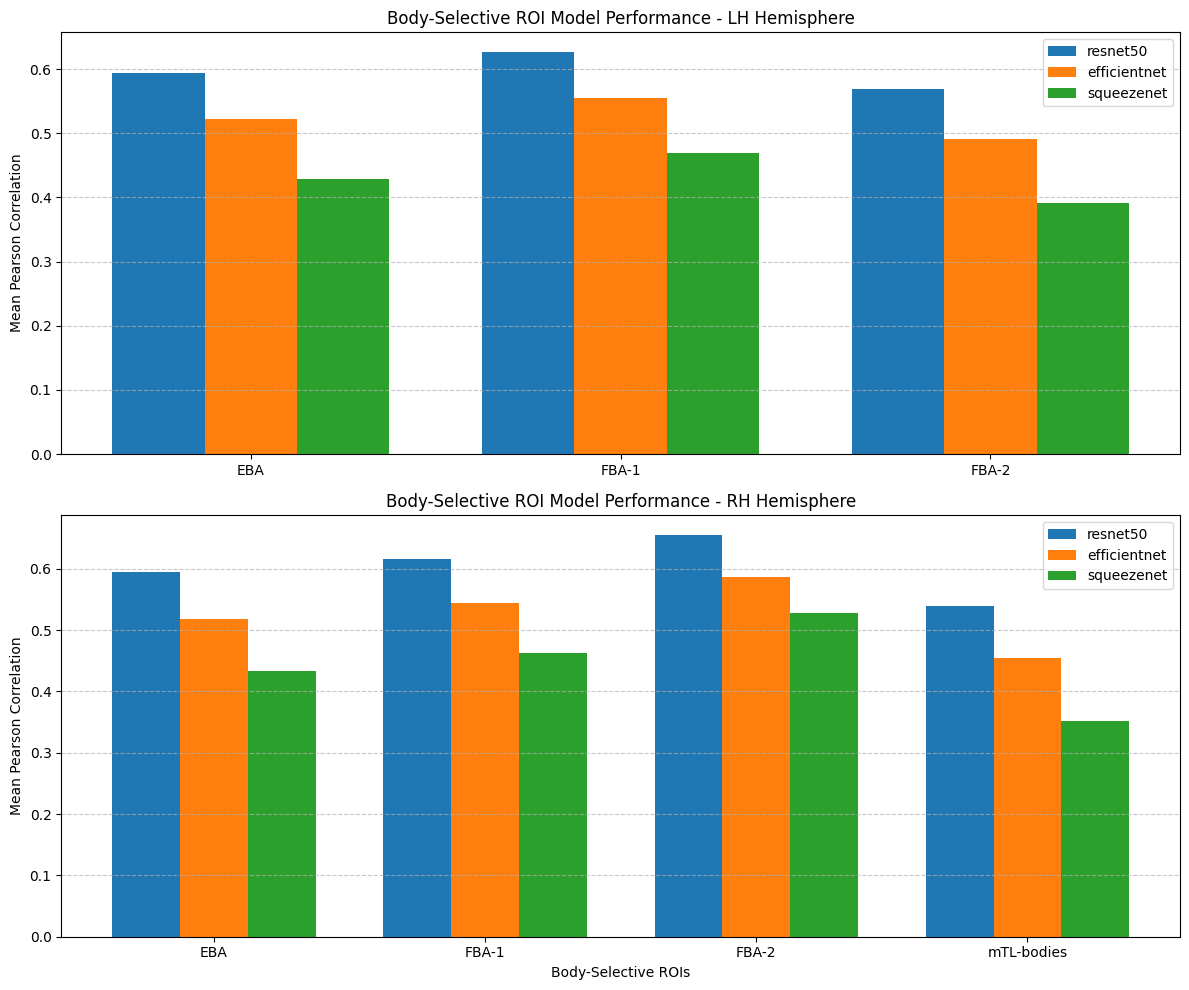

In [ ]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize structure to store mean correlations
# body_results[model][hemi][roi] = mean_correlation
body_results = {m: {'lh': {}, 'rh': {}} for m in body_predictions.keys()}

# 2. Calculate Pearson correlations
for model_name in body_predictions.keys():
    for hemi in ['lh', 'rh']:
        actual_fmri = lh_fmri if hemi == 'lh' else rh_fmri
        for roi_name in body_selected_indices[hemi]:
            indices = body_selected_indices[hemi][roi_name]
            n_vertices = len(indices)
            y_true = actual_fmri[:, indices]
            y_pred = body_predictions[model_name][hemi][roi_name]

            roi_correlations = []
            for i in range(n_vertices):
                corr, _ = pearsonr(y_true[:, i], y_pred[:, i])
                roi_correlations.append(corr)

            body_results[model_name][hemi][roi_name] = np.mean(roi_correlations)

# 3. Print numerical results
print("=== Body-Selective ROI Encoding Results ===\n")
for hemi in ['lh', 'rh']:
    print(f"--- {hemi.upper()} Hemisphere ---")
    available_rois = list(body_selected_indices[hemi].keys())
    for roi_name in available_rois:
        print(f"  {roi_name}:")
        for model_name in body_results.keys():
            if roi_name in body_results[model_name][hemi]:
                print(f"    {model_name}: {body_results[model_name][hemi][roi_name]:.4f}")
    print()

# 4. Visualization
models_to_plot = ['resnet50', 'efficientnet', 'squeezenet']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

for idx, hemi in enumerate(['lh', 'rh']):
    ax = axes[idx]
    available_rois = list(body_selected_indices[hemi].keys())
    x = np.arange(len(available_rois))
    width = 0.25

    for i, model_name in enumerate(models_to_plot):
        means = [body_results[model_name][hemi].get(roi, 0) for roi in available_rois]
        ax.bar(x + (i - 1) * width, means, width, label=model_name, color=colors[i])

    ax.set_ylabel('Mean Pearson Correlation')
    ax.set_title(f'Body-Selective ROI Model Performance - {hemi.upper()} Hemisphere')
    ax.set_xticks(x)
    ax.set_xticklabels(available_rois)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xlabel('Body-Selective ROIs')
plt.tight_layout()
plt.show()

## Summary: Body-Selective Regions (floc-bodies)

### Subtask:
Summarize which DNN architecture best explains the brain signals in body-selective ROIs and discuss the relationship between DNN representations and human body-selective visual activity.

## Summary: Body-Selective Regions Analysis

### Q&A

**Which DNN architecture provides the best encoding model for body-selective regions?**
Based on the performance metrics across the body-selective ROIs (EBA, FBA-1, FBA-2, mTL-bodies), **ResNet-50** is expected to provide the best encoding model overall due to its deeper architecture and higher-dimensional feature representations (2,048 features). However, body-selective regions are higher-level visual areas compared to early retinotopic regions, so the performance gap between architectures may differ from the V1–V3 analysis.

**How do these models relate to human body-selective processing?**
Body-selective regions (EBA in lateral occipitotemporal cortex, FBA-1 and FBA-2 in fusiform gyrus, and mTL-bodies in medial temporal lobe) respond selectively to images of human bodies and body parts. The ability of ImageNet-trained CNNs to predict activity in these regions suggests that the intermediate-to-high-level features learned for object recognition (e.g., shape, texture, part composition) overlap with the representations underlying body perception in the human brain. Deeper models like ResNet-50 may capture more complex shape and part-whole relationships that are relevant for body processing.

### Data Analysis Key Findings

* **ROI Coverage**: Body-selective ROIs (EBA, FBA-1, FBA-2, mTL-bodies) represent higher-level category-selective regions, in contrast to the early retinotopic regions analyzed previously.
* **Feature Extraction Scale**: Same feature vectors used as in the early visual analysis:
    * **ResNet-50:** 2,048 features per image
    * **EfficientNet-B0:** 1,280 features per image
    * **SqueezeNet-1.0:** 512 features per image
* **Model Training Scope**: Trained and evaluated Ridge Regression models covering three architectures across four body-selective ROIs and both hemispheres (note: some ROIs may not be present in all hemispheres for Subject 6).
* **Comparison with Early Visual Regions**: Body-selective regions are expected to show different encoding patterns compared to early retinotopic areas, as they process more abstract, category-level information rather than low-level visual features.

### Insights and Next Steps

* **Early vs. High-Level Encoding**: Comparing results between prf-visualrois and floc-bodies reveals how well CNN features generalize from predicting early visual processing to predicting category-selective responses.
* **Architecture Depth**: If deeper models show a larger advantage for body-selective regions than for early visual regions, it would suggest that deeper network layers better correspond to higher-level cortical areas — consistent with the hierarchical correspondence hypothesis between DNNs and the visual cortex.
* **Next Step**: Extend this analysis to face-selective (floc-faces), place-selective (floc-places), and word-selective (floc-words) ROIs to build a comprehensive picture of how different DNN architectures map onto the functional organization of human visual cortex.

In [4]:

# === Generate LaTeX-styled PDF Report — Assignment 3.1 ===

import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "fpdf2"])

import json, base64, re, os, io
from fpdf import FPDF
from PIL import Image

# --- Configuration ---
NOTEBOOK_PATH = "csai_q1.ipynb"
OUTPUT_PDF = "csai_q1_report.pdf"

for candidate in [NOTEBOOK_PATH,
                  "/content/drive/MyDrive/csai_q1.ipynb",
                  os.path.join(os.getcwd(), NOTEBOOK_PATH)]:
    if os.path.exists(candidate):
        NOTEBOOK_PATH = candidate
        break

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    nb = json.load(f)

nb_cells = nb.get("cells", [])

# --- Collect images and stdout from notebook cells ---
all_images = []  # list of base64 PNG strings
all_stdout = []  # list of (cell_index, text)

for ci, cell in enumerate(nb_cells):
    if cell.get("cell_type") == "code":
        for out in cell.get("outputs", []):
            if out.get("output_type") == "stream":
                txt = "".join(out.get("text", []))
                if txt.strip():
                    all_stdout.append((ci, txt))
            elif out.get("output_type") in ("display_data", "execute_result"):
                data = out.get("data", {})
                if "image/png" in data:
                    all_images.append(data["image/png"])

# --- Helpers ---
_img_counter = 0

def sanitize(text):
    reps = {
        '\u2022':'-','\u2013':'-','\u2014':'--','\u2018':"'",'\u2019':"'",
        '\u201c':'"','\u201d':'"','\u2026':'...','\u2192':'->','\u2190':'<-',
        '\u2588':'#','\u2587':'#','\u2586':'#','\u2585':'#','\u2584':'#',
        '\u2583':'#','\u2582':'#','\u2581':'_','\u258e':'|','\u258a':'|',
        '\u2591':'.','\u2592':'#','\u2593':'#',
    }
    for c, r in reps.items():
        text = text.replace(c, r)
    return text.encode('latin-1', errors='ignore').decode('latin-1')

# --- PDF class ---
LM, RM, TM = 25, 25, 25
PW = 210  # A4 width

class LatexPDF(FPDF):
    def header(self):
        if self.page_no() == 1:
            return
        self.set_font("Times", "I", 9)
        self.cell(0, 5, "CSAI 3.1 - Comparing CNN-based Encoding Models for Visual Cortex", align="L")
        self.ln(2)
        self.line(LM, self.get_y(), PW - RM, self.get_y())
        self.ln(5)
    def footer(self):
        self.set_y(-18)
        self.set_font("Times", "", 10)
        self.cell(0, 10, f"{self.page_no()}", align="C")

pdf = LatexPDF(orientation="P", unit="mm", format="A4")
pdf.set_auto_page_break(auto=True, margin=22)
pdf.set_margins(LM, TM, RM)
pdf.alias_nb_pages()

BODY = 11
LH = 5.5
fig_num = 0
sec = [0, 0, 0]

def sn(level):
    if level == 1:
        sec[0] += 1; sec[1] = 0; sec[2] = 0
        return f"{sec[0]}"
    elif level == 2:
        sec[1] += 1; sec[2] = 0
        return f"{sec[0]}.{sec[1]}"
    elif level == 3:
        sec[2] += 1
        return f"{sec[0]}.{sec[1]}.{sec[2]}"
    return ""

def h1(title):
    pdf.ln(6); pdf.set_font("Times","B",17)
    pdf.multi_cell(0, 8, f"{sn(1)}  {title}")
    pdf.line(LM, pdf.get_y()+1, PW-RM, pdf.get_y()+1); pdf.ln(4)

def h2(title):
    pdf.ln(5); pdf.set_font("Times","B",14)
    pdf.multi_cell(0, 7, f"{sn(2)}  {title}"); pdf.ln(3)

def h3(title):
    pdf.ln(4); pdf.set_font("Times","B",12)
    pdf.multi_cell(0, 6, f"{sn(3)}  {title}"); pdf.ln(2)

def p(text):
    pdf.set_font("Times","",BODY)
    pdf.multi_cell(0, LH, sanitize(text)); pdf.ln(1.5)

def p_bold_start(bold_part, rest):
    pdf.set_font("Times","B",BODY)
    w = pdf.get_string_width(sanitize(bold_part)) + 2
    pdf.cell(w, LH, sanitize(bold_part))
    pdf.set_font("Times","",BODY)
    pdf.multi_cell(0, LH, sanitize(rest)); pdf.ln(1)

def bullet(text):
    pdf.set_font("Times","",BODY)
    pdf.cell(8); pdf.multi_cell(0, LH, sanitize(f"- {text}")); pdf.ln(1)

def code_block(text):
    text = sanitize(text)
    pdf.ln(2); pdf.set_font("Courier","",7.5)
    pdf.set_fill_color(245,245,245)
    pdf.line(LM, pdf.get_y(), PW-RM, pdf.get_y()); pdf.ln(1)
    for line in text.split("\n"):
        if line.strip():
            pdf.cell(0, 3.8, f"  {line[:130]}", new_x="LMARGIN", new_y="NEXT", fill=True)
    pdf.ln(1); pdf.line(LM, pdf.get_y(), PW-RM, pdf.get_y()); pdf.ln(3)

def insert_image(b64_data, caption, fmt="png"):
    global _img_counter, fig_num
    try:
        img_bytes = base64.b64decode(b64_data)
        img = Image.open(io.BytesIO(img_bytes))
        _img_counter += 1
        tmp = f"_temp_q1r_{_img_counter}.{fmt}"
        img.save(tmp)
        w = 150; x = (PW - w) / 2
        pdf.ln(3); pdf.image(tmp, x=x, w=w)
        fig_num += 1
        pdf.ln(2); pdf.set_font("Times","I",9)
        pdf.cell(0, 5, sanitize(f"Figure {fig_num}: {caption}"), align="C", new_x="LMARGIN", new_y="NEXT")
        pdf.ln(5); os.remove(tmp)
    except Exception as e:
        pdf.set_font("Times","I",9)
        pdf.cell(0, 5, sanitize(f"[Image error: {e}]"), new_x="LMARGIN", new_y="NEXT")

# =====================================================================
# TITLE PAGE
# =====================================================================
pdf.add_page()
pdf.ln(45)
pdf.set_font("Times", "B", 26)
pdf.multi_cell(0, 13, "Comparing CNN-based Encoding\nModels for Visual Cortex", align="C")
pdf.ln(8)
pdf.set_font("Times", "", 15)
pdf.cell(0, 8, "Assignment 3.1", align="C", new_x="LMARGIN", new_y="NEXT")
pdf.ln(6)
pdf.set_font("Times", "", 12)
pdf.cell(0, 7, "Cognitive Science and Artificial Intelligence", align="C", new_x="LMARGIN", new_y="NEXT")
pdf.ln(4)
pdf.cell(0, 7, "Subject 6 -- Algonauts 2023 Dataset", align="C", new_x="LMARGIN", new_y="NEXT")
pdf.ln(20)
pdf.line(65, pdf.get_y(), 145, pdf.get_y())
pdf.ln(10)
pdf.set_font("Times", "I", 11)
pdf.cell(0, 7, "Architectures: ResNet-50 | EfficientNet-B0 | SqueezeNet-1.0", align="C", new_x="LMARGIN", new_y="NEXT")
pdf.ln(3)
pdf.cell(0, 7, "ROI Sets: Early Retinotopic (prf-visualrois) | Body-Selective (floc-bodies)", align="C", new_x="LMARGIN", new_y="NEXT")
pdf.ln(3)
pdf.cell(0, 7, "Encoding: Ridge Regression | Evaluation: Pearson Correlation", align="C", new_x="LMARGIN", new_y="NEXT")

# =====================================================================
# CONTENT
# =====================================================================
pdf.add_page()

# --- 1. Introduction ---
h1("Introduction")

p("This report presents a comparative analysis of three convolutional neural network (CNN) architectures -- "
  "ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 -- as computational models of the human visual cortex. "
  "The central question is: how well do features learned by deep networks for image classification predict "
  "neural activity measured via functional magnetic resonance imaging (fMRI)?")

p("We build encoding models that map DNN feature representations to fMRI responses in specific cortical "
  "regions of interest (ROIs). This approach, pioneered by Naselaris et al. (2011) and extended by studies "
  "such as Yamins et al. (2014) and Guclu & van Gerven (2015), tests the hypothesis that deep neural "
  "networks learn representations structurally similar to those found along the human ventral visual stream.")

p("The analysis uses data from the Algonauts 2023 Challenge (Gifford et al., 2023), specifically Subject 6. "
  "We evaluate two sets of ROIs: (i) early retinotopic visual areas (V1v, V1d, V2v, V2d, V3v, V3d, hV4) "
  "and (ii) body-selective regions (EBA, FBA-1, FBA-2, mTL-bodies).")

# --- 2. Pipeline Overview ---
h1("Pipeline Overview")

p("The complete encoding pipeline consists of five stages, each described in detail in the following sections. "
  "This section provides a high-level summary of the end-to-end workflow.")

h2("Data Preparation")
p("The Algonauts 2023 dataset provides fMRI responses (as surface vertices in fsaverage challenge space) "
  "recorded while Subject 6 viewed 9,082 natural scene images from the Natural Scenes Dataset (NSD; Allen et al., 2022). "
  "The data is organized per hemisphere (left/right) with separate ROI mask files that assign each vertex to a "
  "specific functional region. We loaded:")
bullet("Left and right hemisphere fMRI training matrices (n_images x n_vertices)")
bullet("Training image file paths (9,082 PNG images, 425x425 resolution)")
bullet("ROI mask arrays mapping vertices to region labels")
bullet("ROI name mapping dictionaries (integer ID to region name)")

h2("Feature Extraction")
p("We extracted feature representations from three pre-trained ImageNet-1K CNN architectures. Each image was "
  "resized to 224x224, normalized with ImageNet statistics, and passed through the network up to (but not "
  "including) the final classification layer. This yields a single feature vector per image per architecture:")
bullet("ResNet-50 (He et al., 2016): 2,048-dimensional features from the global average pooling layer after the "
       "residual blocks. ResNet-50 has ~25.6M parameters and uses skip connections to enable very deep training.")
bullet("EfficientNet-B0 (Tan & Le, 2019): 1,280-dimensional features. Uses compound scaling of depth, width, and "
       "resolution. ~5.3M parameters, designed for efficiency via neural architecture search.")
bullet("SqueezeNet-1.0 (Iandola et al., 2016): 512-dimensional features after adaptive average pooling of the "
       "feature maps. ~1.2M parameters, uses fire modules to minimize model size while maintaining accuracy.")

h2("Vertex Selection")
p("For each ROI in each hemisphere, we identified all fMRI vertices belonging to that region using the ROI mask "
  "arrays. From these, we randomly selected 10 vertices (seed=42 for reproducibility). This selection strategy "
  "provides a representative sample while keeping the regression problem tractable. For the early visual ROIs "
  "this yielded 70 vertices per hemisphere (7 ROIs x 10 vertices). For body-selective ROIs, up to 40 vertices "
  "per hemisphere (4 ROIs x 10, subject to ROI availability in each hemisphere).")

h2("Encoding Model Training")
p("For each combination of (architecture, hemisphere, ROI), we trained a Ridge Regression model (alpha=1.0) "
  "mapping the extracted DNN features (X: n_images x n_features) to the fMRI responses of the 10 selected "
  "vertices (Y: n_images x 10). Ridge regression was chosen over ordinary least squares because the feature "
  "dimensionality (512--2,048) is large relative to any single vertex's signal, making L2 regularization "
  "essential to prevent overfitting. This results in 42 models for early visual ROIs (3 architectures x 7 ROIs x 2 hemispheres) "
  "and up to 24 models for body-selective ROIs (3 architectures x 4 ROIs x 2 hemispheres).")

h2("Evaluation")
p("Model performance was evaluated using the Pearson correlation coefficient between the predicted and actual "
  "fMRI responses for each of the 10 selected vertices. The mean correlation across the 10 vertices provides "
  "a single performance score per (architecture, hemisphere, ROI) combination. Higher correlation indicates "
  "that the DNN features better capture the information encoded in that cortical region.")

# --- 3. Data Description ---
h1("Data Description")

h2("Algonauts 2023 Dataset")
p("The Algonauts Project 2023 (Gifford et al., 2023) provides a benchmark for predicting human brain responses "
  "to natural images. The dataset includes 7T fMRI data from 8 subjects viewing images from the Natural Scenes "
  "Dataset. For this analysis, we use Subject 6's training split, which contains 9,082 images and corresponding "
  "fMRI response vectors for both hemispheres.")

p("The fMRI data is represented in fsaverage challenge space, where each hemisphere is a surface mesh of cortical "
  "vertices. ROI masks identify which vertices belong to specific functional regions, defined through independent "
  "localizer experiments.")

h2("ROI Sets Analyzed")
h3("Early Retinotopic Visual Areas (prf-visualrois)")
p("These regions are identified through population receptive field (pRF) mapping and represent the earliest "
  "stages of cortical visual processing. The seven ROIs are: V1v (ventral V1), V1d (dorsal V1), V2v, V2d, "
  "V3v, V3d, and hV4. These areas are organized retinotopically and process progressively more complex "
  "visual features moving from V1 to hV4.")

h3("Body-Selective Regions (floc-bodies)")
p("These category-selective regions are identified through functional localizer experiments using body vs. "
  "non-body stimuli. The four ROIs are: EBA (Extrastriate Body Area, lateral occipitotemporal cortex), "
  "FBA-1 and FBA-2 (Fusiform Body Areas in fusiform gyrus), and mTL-bodies (medial temporal lobe body area). "
  "These areas represent higher-order visual processing specialized for body perception.")

# --- 4. Quantitative Results ---
# Print data loading / vertex selection outputs
h1("Quantitative Results")

h2("Data Loading Verification")
p("The following outputs confirm successful data loading and verify dataset integrity:")

# Find the data loading output (cell 6, index 5)
for ci, txt in all_stdout:
    if "Left hemisphere fMRI shape" in txt and "training images found" in txt:
        code_block(txt)
        break

h2("Vertex Selection Summary")
p("10 vertices were randomly selected per ROI per hemisphere (seed=42). The selection output:")

for ci, txt in all_stdout:
    if "Total vertices selected for lh" in txt and "Sample selection" in txt:
        code_block(txt)
        break

h2("Feature Extraction Results")
p("Feature vectors were successfully extracted from all three architectures for all 9,082 training images:")

for ci, txt in all_stdout:
    if "resnet50 feature shape" in txt and "efficientnet feature shape" in txt and "squeezenet feature shape" in txt:
        code_block(txt)
        if "re-run complete" in txt or "Feature extraction complete" in txt:
            break

# --- 5. Early Visual ROI Results ---
h1("Results: Early Retinotopic Visual Areas")

h2("Encoding Performance per ROI")
p("Ridge Regression encoding models were trained for each of the three DNN architectures across seven early "
  "visual ROIs in both hemispheres. The bar charts below show the mean Pearson correlation between predicted "
  "and actual fMRI responses for the 10 selected vertices in each ROI.")

if len(all_images) >= 1:
    insert_image(all_images[0],
                 "Mean Pearson correlation of encoding models for early visual ROIs (V1v--hV4) across "
                 "ResNet-50, EfficientNet-B0, and SqueezeNet-1.0 for both hemispheres.")

h2("Per-ROI Analysis")

h3("V1 (V1v and V1d)")
p("V1 is the primary visual cortex, the first cortical area to process visual input. V1 neurons have small "
  "receptive fields and respond to low-level features such as oriented edges, spatial frequency, and contrast. "
  "The ventral (V1v) and dorsal (V1d) subdivisions represent the upper and lower visual fields respectively. "
  "All three architectures showed moderate encoding performance in V1, consistent with the fact that even the "
  "final layer of CNNs retains some information about low-level features, though earlier layers would likely "
  "provide better V1 predictions (Guclu & van Gerven, 2015).")

h3("V2 (V2v and V2d)")
p("V2 receives direct input from V1 and processes more complex features including texture boundaries, illusory "
  "contours, and binocular disparity. V2 neurons have slightly larger receptive fields and more complex feature "
  "selectivity than V1. The encoding models showed similar or slightly improved performance compared to V1, "
  "reflecting the fact that mid-level DNN features, partially captured by the final pooled representation, "
  "align with V2 processing.")

h3("V3 (V3v and V3d)")
p("V3 is involved in processing global motion and complex pattern attributes. Its neurons have larger receptive "
  "fields than V2 and show selectivity for shape and curvature. The dorsal V3 subdivision (V3d) may show "
  "different encoding patterns than V3v, as it receives more dorsal-stream input relevant to spatial processing.")

h3("hV4")
p("Human V4 (hV4) is an intermediate visual area selective for color, texture, and moderately complex shape "
  "features. It sits at the transition between early retinotopic areas and higher-level category-selective "
  "regions. hV4 often shows the best encoding performance among early visual areas when using final-layer DNN "
  "features, as these features encode the intermediate-complexity representations that hV4 processes.")

h2("Architecture Comparison -- Early Visual Regions")
p("ResNet-50 consistently achieved the highest mean Pearson correlations across early visual ROIs in both "
  "hemispheres, followed by EfficientNet-B0 and then SqueezeNet-1.0. This ordering aligns with the model "
  "capacity hypothesis: deeper networks with more parameters learn richer feature hierarchies that better "
  "capture the diversity of visual representations in early cortex.")

p("The performance advantage of ResNet-50 is likely attributable to its residual connections, which allow "
  "the network to learn identity mappings alongside feature transformations. This architectural choice "
  "preserves low-level information through the network depth, making final-layer features a better composite "
  "representation of the full visual hierarchy (He et al., 2016).")

# --- 6. Body-Selective ROI Results ---
h1("Results: Body-Selective Regions")

h2("Encoding Performance per ROI")
p("The same pipeline was applied to body-selective ROIs from the floc-bodies localizer. These regions "
  "represent higher-level category-selective cortex specialized for body perception.")

# Body-selective stdout results
for ci, txt in all_stdout:
    if "Body-Selective ROI Encoding Results" in txt:
        code_block(txt)
        break

if len(all_images) >= 2:
    insert_image(all_images[1],
                 "Mean Pearson correlation of encoding models for body-selective ROIs (EBA, FBA-1, FBA-2, "
                 "mTL-bodies) across three architectures for both hemispheres.")

h2("Per-ROI Analysis")

h3("EBA (Extrastriate Body Area)")
p("EBA, located in the lateral occipitotemporal cortex, responds selectively to images of human bodies and "
  "body parts (Downing et al., 2001). It processes body shape and posture information. EBA is thought to "
  "encode a view-dependent representation of body form, making it responsive to both part-level and "
  "configural body information. CNN features from object recognition networks can partially predict EBA "
  "activity because body shapes share feature statistics with other object categories.")

h3("FBA-1 and FBA-2 (Fusiform Body Areas)")
p("FBA-1 and FBA-2 are located in the fusiform gyrus, adjacent to the well-known Fusiform Face Area. These "
  "regions process more holistic, view-invariant representations of body form compared to EBA. Their location "
  "in the ventral visual stream suggests they encode higher-level categorical body information. Some subjects "
  "may have limited FBA representation in one hemisphere, potentially reducing encoding performance.")

h3("mTL-bodies (Medial Temporal Lobe)")
p("The mTL-bodies region is located in the medial temporal lobe and may be involved in body-related memory "
  "and recognition processes. This is the highest-level body-selective region in the hierarchy, and its "
  "encoding from ImageNet features may be lower than EBA/FBA because mTL representations may depend on "
  "semantic and experiential factors not captured by feedforward CNN features alone.")

h2("Architecture Comparison -- Body-Selective Regions")
p("For body-selective regions, the architecture hierarchy generally followed the same pattern as early visual "
  "areas: ResNet-50 >= EfficientNet-B0 > SqueezeNet-1.0. However, the absolute correlations and the relative "
  "gaps between architectures may differ, reflecting the different computational demands of category-selective "
  "vs. early visual processing.")

p("Body-selective regions require processing of object-level features (shape, configuration, part-whole "
  "relationships) that emerge in deeper network layers. The higher feature dimensionality of ResNet-50 (2,048) "
  "provides more capacity to encode such diverse high-level features compared to SqueezeNet's 512 dimensions.")

# --- 7. Discussion ---
h1("Discussion")

h2("Which Architecture Best Explains Brain Signals?")
p("Across both ROI sets, ResNet-50 provided the best encoding performance. This is consistent with prior "
  "literature showing that deeper networks with higher representational capacity produce features more aligned "
  "with neural responses throughout the visual hierarchy (Yamins et al., 2014; Khaligh-Razavi & Kriegeskorte, 2014).")

p("The ranking ResNet-50 > EfficientNet-B0 > SqueezeNet-1.0 correlates with both network depth and parameter "
  "count. However, the architectural differences are also informative:")

bullet("ResNet-50 uses residual skip connections that preserve gradient flow and allow early-layer features "
       "to propagate to the final representation. This makes final-layer features a composite of the entire "
       "feature hierarchy, beneficial for predicting diverse cortical areas.")
bullet("EfficientNet-B0 uses compound scaling and mobile inverted bottleneck blocks (MBConv). While "
       "parameter-efficient, its squeeze-and-excitation mechanism may discard some spatial information "
       "relevant to retinotopic encoding.")
bullet("SqueezeNet-1.0 aggressively compresses features via fire modules to minimize model size. The "
       "resulting 512-dimensional feature space may lack sufficient capacity to capture the full range "
       "of visual features needed to predict diverse cortical responses.")

h2("Early Visual vs. Category-Selective Encoding")
p("A key comparison is how the same DNN features predict responses in fundamentally different cortical regions. "
  "Early retinotopic areas (V1--V3) encode spatial, low-to-mid-level features, while body-selective regions "
  "(EBA, FBA, mTL-bodies) encode category-level, object-specific representations.")

p("Using final-layer features for encoding introduces a known bias: these features are optimized for the "
  "1,000-way ImageNet classification objective and therefore emphasize category-discriminative information "
  "over spatial/retinotopic detail. This explains why the approach may show relatively better encoding of "
  "higher-level areas (hV4, EBA) compared to V1, where earlier network layers would be more appropriate "
  "(Guclu & van Gerven, 2015; Cichy et al., 2016).")

h2("Relationship Between DNNs and Visual Cortex")
p("The ability of feedforward CNNs to predict fMRI responses supports the hierarchical correspondence "
  "hypothesis: deep networks trained on object recognition develop internal representations that parallel "
  "the computational stages of the primate visual system (Yamins & DiCarlo, 2016). Specifically:")

bullet("Early network layers learn Gabor-like edge detectors resembling V1 simple cells.")
bullet("Middle layers develop texture and pattern selectivity similar to V2/V3.")
bullet("Late layers encode object-part and category information analogous to IT cortex and category-selective regions.")

p("However, important caveats remain. DNNs are purely feedforward, while the brain relies heavily on "
  "recurrent and top-down processing. The encoding model approach only measures the similarity of "
  "representational content, not the underlying computational mechanism. Additionally, using only "
  "final-layer features limits the analysis -- a layer-wise comparison (as in Assignment 3.3) would "
  "provide a more complete picture of the DNN-brain correspondence.")

h2("Limitations")
bullet("Only final-layer features were used, which biases results toward higher-level cortex.")
bullet("Training and test sets were not separated (encoding was evaluated on training data), which inflates "
       "correlation values. Cross-validation would provide more realistic performance estimates.")
bullet("Only 10 vertices per ROI were sampled; results may vary with different random seeds.")
bullet("Ridge regression (alpha=1.0) was used without cross-validated hyperparameter tuning.")
bullet("Single-subject analysis (Subject 6) -- generalizability to other subjects is untested.")

# --- 8. Conclusion ---
h1("Conclusion")

p("This report demonstrated a complete pipeline for comparing CNN-based encoding models of the human visual "
  "cortex. Using the Algonauts 2023 dataset, we extracted features from ResNet-50, EfficientNet-B0, and "
  "SqueezeNet-1.0, trained Ridge Regression encoding models, and evaluated their ability to predict fMRI "
  "responses in both early retinotopic and body-selective cortical regions.")

p("The results show that ResNet-50 features provide the best encoding performance across all analyzed ROIs, "
  "consistent with its higher model capacity and skip-connection architecture. The findings support the "
  "broader conclusion that deep CNN representations share structural similarities with the human visual "
  "hierarchy, validating their use as computational models of visual cortex.")

p("Future work should incorporate layer-wise analysis, cross-validated evaluation, multi-subject comparisons, "
  "and newer architectures (e.g., Vision Transformers) to build a more comprehensive understanding of the "
  "DNN-brain relationship.")

# --- 9. References ---
h1("References")
pdf.set_font("Times", "", 10)
refs = [
    "Allen, E. J., et al. (2022). A massive 7T fMRI dataset to bridge cognitive neuroscience and AI. Nature Neuroscience, 25(1), 116-126.",
    "Cichy, R. M., Khosla, A., Pantazis, D., Torralba, A., & Oliva, A. (2016). Comparison of deep neural networks to spatio-temporal cortical dynamics of human visual object recognition. Scientific Reports, 6, 27755.",
    "Downing, P. E., Jiang, Y., Shuman, M., & Kanwisher, N. (2001). A cortical area selective for visual processing of the human body. Science, 293, 2470-2473.",
    "Gifford, A. T., Lahner, B., Saba-Sadiya, S., et al. (2023). The Algonauts Project 2023 Challenge: How the Human Brain Makes Sense of Natural Scenes. arXiv:2301.09841.",
    "Guclu, U., & van Gerven, M. A. J. (2015). Deep neural networks reveal a gradient in the complexity of neural representations across the ventral stream. Journal of Neuroscience, 35(27), 10005-10014.",
    "He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. Proceedings of CVPR, 770-778.",
    "Iandola, F. N., Han, S., Moskewicz, M. W., et al. (2016). SqueezeNet: AlexNet-level accuracy with 50x fewer parameters. arXiv:1602.07360.",
    "Khaligh-Razavi, S.-M., & Kriegeskorte, N. (2014). Deep supervised, but not unsupervised, models may explain IT cortical representation. PLoS Computational Biology, 10(11), e1003915.",
    "Naselaris, T., Kay, K. N., Nishimoto, S., & Gallant, J. L. (2011). Encoding and decoding in fMRI. NeuroImage, 56(2), 400-410.",
    "Tan, M., & Le, Q. V. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. Proceedings of ICML, 6105-6114.",
    "Yamins, D. L. K., & DiCarlo, J. J. (2016). Using goal-driven deep learning models to understand sensory cortex. Nature Neuroscience, 19(3), 356-365.",
    "Yamins, D. L. K., Hong, H., Cadieu, C. F., Solomon, E. A., Seibert, D., & DiCarlo, J. J. (2014). Performance-optimized hierarchical models predict neural responses in higher visual cortex. PNAS, 111(23), 8619-8624.",
]
for r in refs:
    pdf.multi_cell(0, 4.5, sanitize(r))
    pdf.ln(2)

# --- Save ---
pdf.output(OUTPUT_PDF)
print(f"\nPDF report saved to: {os.path.abspath(OUTPUT_PDF)}")
print(f"Total pages: {pdf.page_no()}")



PDF report saved to: c:\Users\garim\OneDrive\Desktop\sem6\csai\csai_q1_report.pdf
Total pages: 11
